   1. Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)

In [1]:
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
# Numerical libraries
import numpy as np   

from sklearn.model_selection import train_test_split

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# to handle data in form of rows and columns 
import pandas as pd    

# importing ploting libraries
import matplotlib.pyplot as plt   

#importing seaborn for statistical plots
import seaborn as sns

In [217]:
from sklearn.model_selection import train_test_split

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import numpy as np   

from sklearn.model_selection import train_test_split

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# to handle data in form of rows and columns 
import pandas as pd    

# importing ploting libraries
import matplotlib.pyplot as plt   

#importing seaborn for statistical plots
import seaborn as sns
from scipy.stats import zscore
from sklearn import svm

In [79]:
df = pd.read_csv("vehicle.csv")  

In [80]:
df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

In [107]:
df.shape

(846, 19)

In [108]:
df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [109]:
numeric_cols = df.drop('class', axis=1)

# This is the dependent variable
car_names = pd.DataFrame(df[['class']])


numeric_cols = numeric_cols.apply(lambda x: x.fillna(x.median()),axis=0)
df = numeric_cols.join(car_names)   # Recreating mpg_df by combining numerical columns with car names

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    846 non-null float64
distance_circularity           846 non-null float64
radius_ratio                   846 non-null float64
pr.axis_aspect_ratio           846 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  846 non-null float64
elongatedness                  846 non-null float64
pr.axis_rectangularity         846 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                846 non-null float64
scaled_variance.1              846 non-null float64
scaled_radius_of_gyration      846 non-null float64
scaled_radius_of_gyration.1    846 non-null float64
skewness_about                 846 non-null float64
skewness_about.1               846 non-null float64
skewness_about.2               846 non-null float64
hollows_ratio    

In [110]:
df.shape

(846, 19)

In [111]:
df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [99]:
# class distribution
print(df.groupby('class').size())

class
bus    218
car    429
van    199
dtype: int64


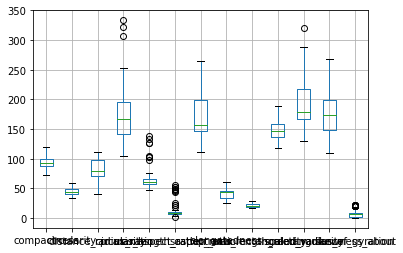

In [100]:
boxplot = df.boxplot(column=['compactness', 'circularity', 'distance_circularity', 'radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_radius_of_gyration', 'skewness_about'])

In [192]:
X = df.drop('class', axis=1)

# Copy the 'class' column alone into the y dataframe. This is the dependent variable
Y = pd.DataFrame(df[['class']])

In [193]:
from scipy import stats
import numpy as np
z = np.abs(stats.zscore(X))
print(z)

[[0.16058035 0.51807313 0.05717723 ... 0.3808703  0.31201194 0.18395733]
 [0.32546965 0.62373151 0.12074088 ... 0.15679779 0.01326483 0.45297703]
 [1.25419283 0.84430302 1.51914112 ... 0.40338349 0.14937355 0.04944748]
 ...
 [1.49721783 1.49676282 1.20132288 ... 0.96356477 0.31201194 0.72199673]
 [0.93303214 1.43930625 0.26064101 ... 1.38919659 0.17590322 0.08506238]
 [1.05454464 1.43930625 1.02340478 ... 0.60494281 0.47465032 0.75761164]]


In [194]:
threshold = 3
print(np.where(z > 3))

(array([  4,   4,   4,  37,  37,  37,  37,  44,  85, 100, 100, 100, 123,
       132, 135, 135, 135, 135, 291, 291, 321, 321, 388, 388, 388, 388,
       388, 391, 396, 513, 516, 523, 523, 623, 687, 687, 706, 706, 706,
       733, 761, 835, 835, 835], dtype=int64), array([ 4,  5, 13,  3,  4,  5, 13,  0, 11,  4,  5, 13, 14, 15,  3,  4,  5,
       13,  4,  5, 10, 11,  3,  4,  5, 10, 13,  5, 10, 15, 14,  4,  5, 14,
       10, 11,  4,  5, 13, 10, 14,  8, 10, 11], dtype=int64))


In [195]:
X["class"] = Y

In [196]:
X.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [197]:
X_o = X[(z < 3).all(axis=1)]

In [198]:
X.shape

(846, 19)

In [204]:
X_o.shape

(824, 19)

In [205]:
X = X_o.drop('class', axis=1)

# Copy the 'class' column alone into the y dataframe. This is the dependent variable
Y = pd.DataFrame(X_o[['class']])

2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)

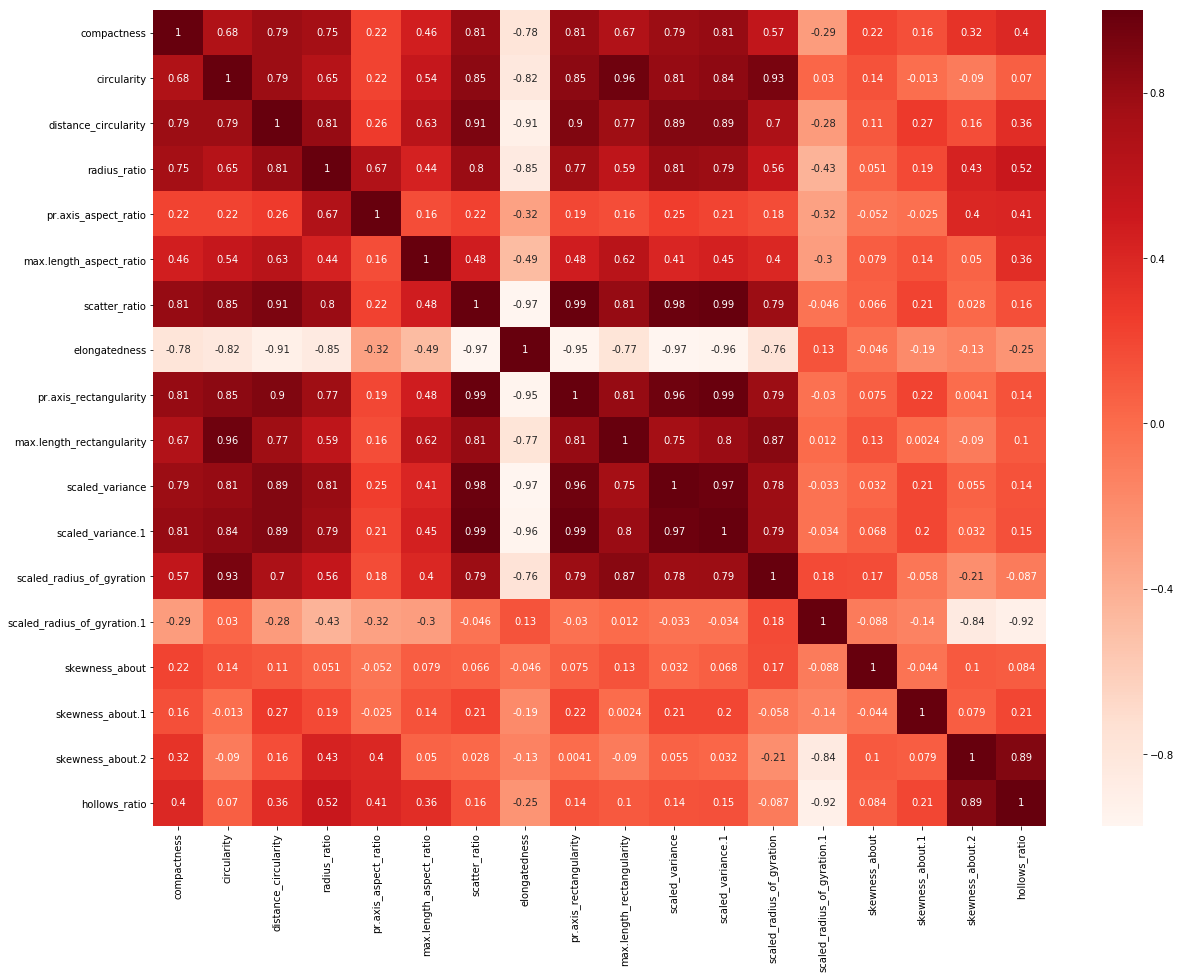

In [206]:
#X_o.corr()
plt.figure(figsize=(20,15))
cor = X.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [207]:
columns = np.full((corr.shape[0],), True, dtype=bool)
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[0]):
        if corr.iloc[i,j] >= 0.9:
            if columns[j]:
                columns[j] = False
selected_columns = X.columns[columns]
X = X[selected_columns]

In [210]:
Y.shape

(824, 1)

3. Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points

In [237]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.decomposition import PCA
from scipy.stats import zscore

In [221]:
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00121507  0.68217024  0.78822181  0.75243342  0.21698852  0.46386185
  -0.78575974 -0.29127966  0.22075084  0.15984485  0.31959319  0.39657645]
 [ 0.68217024  1.00121507  0.79171052  0.64957366  0.22025961  0.541045
  -0.82123179  0.02955186  0.14430926 -0.01286449 -0.09028883  0.06969066]
 [ 0.78822181  0.79171052  1.00121507  0.81531437  0.26136013  0.6282153
  -0.91114978 -0.28197451  0.10625657  0.26914753  0.1611285   0.35768519]
 [ 0.75243342  0.64957366  0.81531437  1.00121507  0.67238671  0.44497519
  -0.85032469 -0.42786646  0.05149701  0.18807334  0.43547261  0.52425001]
 [ 0.21698852  0.22025961  0.26136013  0.67238671  1.00121507  0.1651475
  -0.3213513  -0.31877894 -0.05183531 -0.02492353  0.40277468  0.41403888]
 [ 0.46386185  0.541045    0.6282153   0.44497519  0.1651475   1.00121507
  -0.48613393 -0.30173529  0.07959367  0.14037242  0.05010063  0.36011497]
 [-0.78575974 -0.82123179 -0.91114978 -0.85032469 -0.3213513  -0.48613393
   1.00121507 

In [222]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.36253106 -0.13691845 -0.15315976 -0.07409717  0.10108643 -0.36538288
   0.75497867  0.06465652 -0.28091575 -0.14358164  0.04919598  0.03209834]
 [-0.30434907 -0.37652755  0.02642651 -0.15269787 -0.09020043 -0.04051612
  -0.33820279  0.75908324 -0.16036263  0.04960825 -0.07786088 -0.08353451]
 [-0.38503586 -0.21871781 -0.07298549  0.10497509 -0.03680041 -0.0761514
  -0.29172813 -0.37635607 -0.11818685  0.04687123  0.649826   -0.33944349]
 [-0.40359433 -0.02808784  0.24113478 -0.02432492  0.21316598  0.02710261
  -0.01473536 -0.25154913 -0.06349219  0.7238134  -0.35163784  0.12779027]
 [-0.22261272  0.1602254   0.58571244 -0.17352792  0.28337347  0.55290796
   0.14319475  0.0692907  -0.1015461  -0.31122532  0.16505051 -0.0766306 ]
 [-0.27278371 -0.12572784 -0.18854673  0.10045323 -0.65130029  0.52026356
   0.27032382 -0.05581524  0.23368703  0.03596888 -0.15098103 -0.11994009]
 [ 0.36768593  0.26899385 -0.08757478 -0.0400615  -0.11368207  0.19970524
   0.2141166   

In [223]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.317623477592429, array([-0.36253106, -0.30434907, -0.38503586, -0.40359433, -0.22261272,
       -0.27278371,  0.36768593,  0.24320607, -0.06409601, -0.10268358,
       -0.22138697, -0.28779848])), (2.510839857399075, array([-0.13691845, -0.37652755, -0.21871781, -0.02808784,  0.1602254 ,
       -0.12572784,  0.26899385, -0.47252227, -0.00698293,  0.02979636,
        0.50505884,  0.44465522])), (1.1170576554219527, array([-0.15315976,  0.02642651, -0.07298549,  0.24113478,  0.58571244,
       -0.18854673, -0.08757478,  0.13133576, -0.64301032, -0.29461455,
       -0.01414566, -0.09156095])), (1.0881408525767422, array([-0.07409717, -0.15269787,  0.10497509, -0.02432492, -0.17352792,
        0.10045323, -0.0400615 , -0.01620257, -0.55386945,  0.77479966,
       -0.09335683,  0.04135086])), (0.7719701641901324, array([ 0.10108643, -0.09020043, -0.03680041,  0.21316598,  0.28337347,
       -0.65130029, -0.11368207,  0.22182475,  0.38292979,  0.44113541,
        0.07847644, -0.14434253]

In [224]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 13 entries as there are 13 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 13 entries with 13 th entry 
# cumulative reaching almost 100%


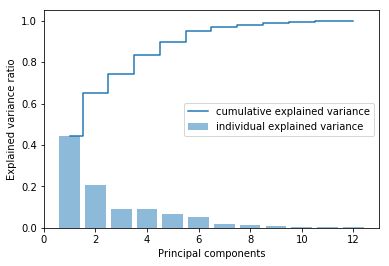

In [227]:
plt.bar(range(1,13), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,13),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

In [228]:
# P_reduce represents reduced mathematical space....

P_reduce = np.array(eigvectors_sorted[0:6])   # Reducing from 13 to 6 dimension space

X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot

In [230]:
Proj_data_df.head()

,0,1,2,3,4,5
0,-1.088964,0.073777,0.882592,0.030514,0.055514,1.574257
1,0.653155,0.450517,-1.190535,0.132009,-0.449838,0.214799
2,-2.693546,-1.307173,-0.430373,-1.304510,0.564237,0.570562
3,-0.741324,2.609651,-0.243835,-0.192520,-0.798965,-0.071754
4,0.127150,-3.643511,-0.413554,0.233543,0.768699,-2.424536


In [233]:
Proj_data_df.shape

(824, 6)

In [234]:
Y.shape

(824, 1)

4. Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

In [235]:
X_train, X_test, y_train, y_test = train_test_split(Proj_data_df, y, test_size=0.30, random_state=1)

In [267]:
#Running SVM with default hyperparameter

from sklearn.svm import SVC
from sklearn import metrics
svc=SVC() #Default hyperparameters
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.8991935483870968


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


In [268]:
#Default Linear kernel

svc=SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.7701612903225806


In [269]:
# Default RBF kernel

svc=SVC(kernel='rbf')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.8991935483870968


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


In [273]:
#Performing K-fold cross validation with different kernels
# CV on Linear kernel

from sklearn.model_selection import cross_val_score
svc=SVC(kernel='linear')
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy') #cv is cross validation
print(scores)

[0.91666667 0.95238095 0.92682927 0.92682927 0.97560976 0.8902439
 0.92682927 0.95121951 0.96341463 0.95121951]


In [274]:
print(scores.mean())

0.9381242740998837


In [275]:
# CV on rbf kernel

svc=SVC(kernel='rbf')
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy') #cv is cross validation
print(scores)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarni

[0.51190476 0.52380952 0.52439024 0.52439024 0.52439024 0.51219512
 0.51219512 0.53658537 0.51219512 0.52439024]


In [276]:
print(scores.mean())

0.5206445993031358


In [ ]:
## Taking all the values of C [0.01, 0.05, 0.5, 1] and checking out the accuracy score with kernel as linear.

In [279]:
C_range=[0.01, 0.05, 0.5, 1]
acc_score=[]
for c in C_range:
    svc = SVC(kernel='linear', C=c)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)

[0.9321138211382115, 0.9260452961672476, 0.9357142857142857, 0.9381242740998837]


In [ ]:
## Taking all the values of C [0.01, 0.05, 0.5, 1] and checking out the accuracy score with kernel as rbf.

In [283]:
C_range=[0.01, 0.05, 0.5, 1]
acc_score=[]
for c in C_range:
    svc = SVC(kernel='rbf', C=c)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarni

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarni

[0.512137049941928, 0.512137049941928, 0.512137049941928, 0.5206445993031358]


In [ ]:
# Now performing SVM by taking hyperparameter C= 1 and kernel as linear....As on C=1 we got the best result

In [285]:
from sklearn.svm import SVC
svc= SVC(kernel='linear',C=1)
svc.fit(X_train,y_train)
y_predict=svc.predict(X_test)
accuracy_score= metrics.accuracy_score(y_test,y_predict)
print(accuracy_score)

0.7701612903225806


In [287]:
# With K-fold cross validation(where K=10)
svc=SVC(kernel='linear',C=0.1)
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(scores)

[0.9047619  0.92857143 0.91463415 0.92682927 0.97560976 0.91463415
 0.91463415 0.95121951 0.95121951 0.91463415]


In [288]:
print(scores.mean())

0.9296747967479675


In [292]:
#  perform Grid search technique to find the best parameter

svm_model= SVC()

In [293]:
tuned_parameters = {
 'C': ([0.01, 0.05, 0.5, 1]) , 'kernel': ['linear'],
 'C': ([0.01, 0.05, 0.5, 1]) , 'kernel': ['rbf'],
                    }

In [294]:
from sklearn.model_selection import GridSearchCV


model_svm = GridSearchCV(svm_model, tuned_parameters,cv=10,scoring='accuracy')

In [295]:
model_svm.fit(X_train, y_train)
print(model_svm.best_score_)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarni

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarni

0.8871527777777778


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


In [297]:
print(model_svm.best_params_)

{'C': 0.5, 'kernel': 'rbf'}


In [298]:
y_pred= model_svm.predict(X_test)
print(metrics.accuracy_score(y_pred,y_test))

0.8951612903225806


** As per our Grid Search the best parameter was C: 0.5 and best Kernal is 'rbf' where we got the accuracy of 89%